In [1]:
import sys
from matplotlib import pyplot as plt
from sklift.metrics import uplift_at_k
import seaborn as sns
import numpy as np
import pandas as pd
import joblib
from sklift.models import ClassTransformation
from sklearn.calibration import CalibratedClassifierCV

from catboost import CatBoostClassifier, CatBoostRegressor
from sklift.metrics import qini_auc_score

# install uplift library scikit-uplift and other libraries
#!{sys.executable} -m pip install scikit-uplift dill catboost

# %config InlineBackend.figure_format = 'svg'
# %matplotlib inline

## Input dataset

In [23]:
# dataset = joblib.load("data/hillstrom.joblib")

In [24]:
# dataset.keys()

In [25]:
# # 1. Start by merging everything into one Master DataFrame
# # Assuming dataset.data is a pandas DataFrame or similar-structured object
# df_input = pd.DataFrame(dataset.data)

# # 2. Add your columns
# df_input['treatment'] = dataset.treatment # Note: or whatever your source for the treatment col is
# df_input[dataset.target.columns] = dataset.target

In [26]:
#df_input.to_parquet('data/hillstrom.parquet', index=False)

In [150]:
df_input=pd.read_parquet('data/hillstrom.parquet')
target_cols = ['treatment', 'visit', 'conversion','spend']

In [151]:
df_input.head(20)

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0
5,6,2) $100 - $200,134.83,0,1,Surburban,0,Phone,Womens E-Mail,1,0,0.0
6,9,3) $200 - $350,280.20,1,0,Surburban,1,Phone,Womens E-Mail,0,0,0.0
7,9,1) $0 - $100,46.42,0,1,Urban,0,Phone,Womens E-Mail,0,0,0.0
8,9,5) $500 - $750,675.07,1,1,Rural,1,Phone,Mens E-Mail,0,0,0.0
9,10,1) $0 - $100,32.84,0,1,Urban,1,Web,Womens E-Mail,0,0,0.0


### Feature leakage check

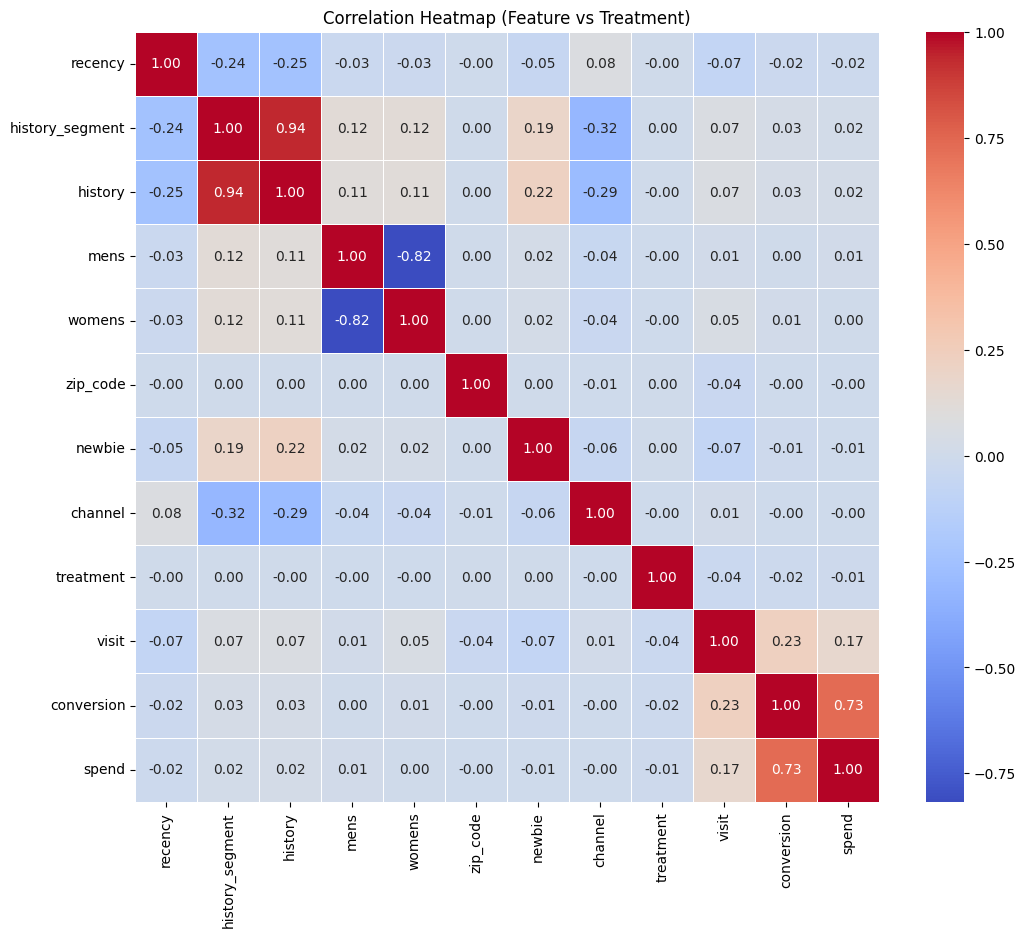

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a copy for the heatmap
# We convert everything to numeric so we can calculate correlations
corr_df = df_input.copy()

# 2. Encode categorical columns to numeric
# 'treatment' must be encoded: Womens E-Mail=2, Mens E-Mail=1, No E-Mail=0
#corr_df['treatment'] = corr_df['treatment'].map({'Womens E-Mail': 2, 'Mens E-Mail': 1, 'No E-Mail': 0})

# Encode others: Zip_Code, Channel, History_Segment
cat_cols = ['zip_code', 'channel', 'history_segment','treatment']
for col in cat_cols:
    corr_df[col] = corr_df[col].astype('category').cat.codes

# 3. Calculate Correlation Matrix
corr_matrix = corr_df.corr()

# 4. Plot Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Feature vs Treatment)")
plt.show()

In [31]:
df_input.columns

Index(['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code',
       'newbie', 'channel', 'treatment', 'visit', 'conversion', 'spend'],
      dtype='object')

## Men Modelling 
Filter out Women E-mail treatment
Method:
- Model 1: Classification to decide conversion - on all data
- Model 2: Regression to decide spending amount - on those spend >0 

#### Model 1 - Classification 

In [6]:
df_men=df_input[df_input['treatment']!='Womens E-Mail']

In [12]:
df_men[df_men['conversion']==1]['spend'].describe()

count    389.000000
mean     113.676144
std      108.911123
min       29.990000
25%       30.940000
50%       73.810000
75%      149.580000
max      499.000000
Name: spend, dtype: float64

In [13]:
df_men[df_men['conversion']==0]['spend'].describe()

count    42224.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: spend, dtype: float64

In [14]:
df_men.shape

(42613, 12)

In [15]:
df_men['treatment'].value_counts()

treatment
Mens E-Mail    21307
No E-Mail      21306
Name: count, dtype: int64

In [16]:
treatment_map = {'No E-Mail': 0, 'Mens E-Mail': 1}
df_men['treatment'] = df_men['treatment'].map(treatment_map)

C:\Users\vncpyy7h\AppData\Local\Temp\ipykernel_31332\4169295510.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_men['treatment'] = df_men['treatment'].map(treatment_map)


In [18]:
df_men['treatment'].value_counts()

treatment
1    21307
0    21306
Name: count, dtype: int64

In [19]:
df_men

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,visit,conversion,spend
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,0,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,1,0,0,0.0
8,9,5) $500 - $750,675.07,1,1,Rural,1,Phone,1,0,0,0.0
13,2,2) $100 - $200,101.64,0,1,Urban,0,Web,1,1,0,0.0
14,4,3) $200 - $350,241.42,0,1,Rural,1,Multichannel,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
63994,7,1) $0 - $100,86.46,0,1,Urban,0,Web,1,0,0,0.0
63995,10,2) $100 - $200,105.54,1,0,Urban,0,Web,1,0,0,0.0
63996,5,1) $0 - $100,38.91,0,1,Urban,1,Phone,1,0,0,0.0
63997,6,1) $0 - $100,29.99,1,0,Urban,1,Phone,1,0,0,0.0


In [22]:
from sklearn.model_selection import train_test_split

stratify_cols = pd.concat([df_men['treatment'], df_men['conversion']], axis=1)

X_train, X_val, trmnt_train, trmnt_val, y_train, y_val = train_test_split(
    df_men.drop(columns=target_cols),
    df_men['treatment'],
    df_men['conversion'],
    stratify=stratify_cols,
    test_size=0.3,
    random_state=41
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")

Train shape: (29829, 8)
Validation shape: (12784, 8)


In [23]:
z_val = np.where((trmnt_val == 1) & (y_val == 1), 1,
          np.where((trmnt_val == 0) & (y_val == 0), 1, 0))

In [24]:
estimator = CatBoostClassifier(
    iterations=1000,          # Allow up to 1000, but early stopping will cut it short
    learning_rate=0.03,       # Slower is safer (standard for CatBoost)
    depth=4,                  # VERY IMPORTANT: Keep between 3 and 5. Deep trees memorize noise.
    l2_leaf_reg=10,           # Higher values (e.g., 10-20) force the model to be simpler
    min_data_in_leaf=50,      # Force each tree leaf to represent at least 50 users
    random_strength=1,        # Prevents tree from overfitting to specific training samples
    
    # Early Stopping
    early_stopping_rounds=50,
    
    # Categorical handling
    cat_features=['womens', 'mens', 'channel', 'zip_code', 'history_segment', 'newbie'],
    
    # Misc
    random_state=42,
    thread_count=1,
    verbose=50                # Print less often to keep your console clean
)

ct_model = ClassTransformation(estimator=estimator)

In [25]:
ct_model.fit(
    X=X_train, y=y_train, treatment=trmnt_train,
    estimator_fit_params={'eval_set': (X_val, z_val),'early_stopping_rounds': 50} # Now the model has eyes!
)

0:	learn: 0.6931355	test: 0.6931492	best: 0.6931492 (0)	total: 163ms	remaining: 2m 43s
50:	learn: 0.6926716	test: 0.6931826	best: 0.6931492 (0)	total: 2.08s	remaining: 38.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6931492263
bestIteration = 0

Shrink model to first 1 iterations.


,estimator,"CatBoostClass...1, verbose=50)"


In [26]:
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd
from sklift.metrics import uplift_at_k
from catboost import CatBoostClassifier
from sklift.models import ClassTransformation

# 1. Define X, y, t
X = df_men.drop(columns=target_cols)
y = df_men['conversion']
t = df_men['treatment']

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store results
results = []
trained_models = []


for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    # Slice the data
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
    t_train_fold, t_val_fold = t.iloc[train_index], t.iloc[val_index]
    
    # Generate the Z-label
    z_train_fold = np.where((t_train_fold == 1) & (y_train_fold == 1), 1,
                     np.where((t_train_fold == 0) & (y_train_fold == 0), 1, 0))
    z_val_fold = np.where((t_val_fold == 1) & (y_val_fold == 1), 1,
                   np.where((t_val_fold == 0) & (y_val_fold == 0), 1, 0))
    
    # Initialize and Fit
    estimator = CatBoostClassifier(
        iterations=1000, depth=4, learning_rate=0.05,
        cat_features=['womens', 'mens', 'channel', 'zip_code', 'history_segment', 'newbie'],
        early_stopping_rounds=50, random_state=42, thread_count=1, verbose=0
    )
    
    ct_model = ClassTransformation(estimator=estimator)
    
    ct_model.fit(
        X_train_fold, y_train_fold, treatment=t_train_fold,
        estimator_fit_params={
            'eval_set': (X_val_fold, z_val_fold),
            'early_stopping_rounds': 50
        }
    )
    
    # Predict
    train_preds = ct_model.predict(X_train_fold)
    val_preds = ct_model.predict(X_val_fold)
    
    # Score
    train_score = uplift_at_k(y_train_fold, train_preds, t_train_fold, strategy='overall', k=0.1)
    val_score = uplift_at_k(y_val_fold, val_preds, t_val_fold, strategy='overall', k=0.1)
    
    results.append({
        "Fold": fold + 1,
        "Train Uplift": train_score,
        "Validation Uplift": val_score
    })

    trained_models.append(ct_model)


# Convert to DataFrame
results_df = pd.DataFrame(results)

# Add average row
avg_row = pd.DataFrame({
    "Fold": ["Average"],
    "Train Uplift": [results_df["Train Uplift"].mean()],
    "Validation Uplift": [results_df["Validation Uplift"].mean()]
})

results_df = pd.concat([results_df, avg_row], ignore_index=True)
print(results_df)

      Fold  Train Uplift  Validation Uplift
0        1      0.007749           0.004902
1        2      0.009621           0.011055
2        3      0.006333           0.011494
3        4      0.012263           0.004256
4        5      0.008464           0.008603
5  Average      0.008886           0.008062


In [31]:
ct_model=trained_models[2]

In [32]:
## Save model
joblib.dump(ct_model, 'models/mens_uplift_model_spending_classification.pkl')

['models/mens_uplift_model_spending_classification.pkl']

In [33]:
# 1. Get predictions for both sets
# Remember: ct_model_mens is the one you already trained on X_train
train_preds = ct_model.predict(X_train)
val_preds = ct_model.predict(X_val)

# 2. Calculate Qini scores
qini_train = qini_auc_score(
    y_true=y_train, 
    uplift=train_preds, 
    treatment=trmnt_train
)

qini_val = qini_auc_score(
    y_true=y_val, 
    uplift=val_preds, 
    treatment=trmnt_val
)

print(f"Qini Score (Train): {qini_train:.4f}")
print(f"Qini Score (Validation): {qini_val:.4f}")

Qini Score (Train): -0.0396
Qini Score (Validation): 0.1441


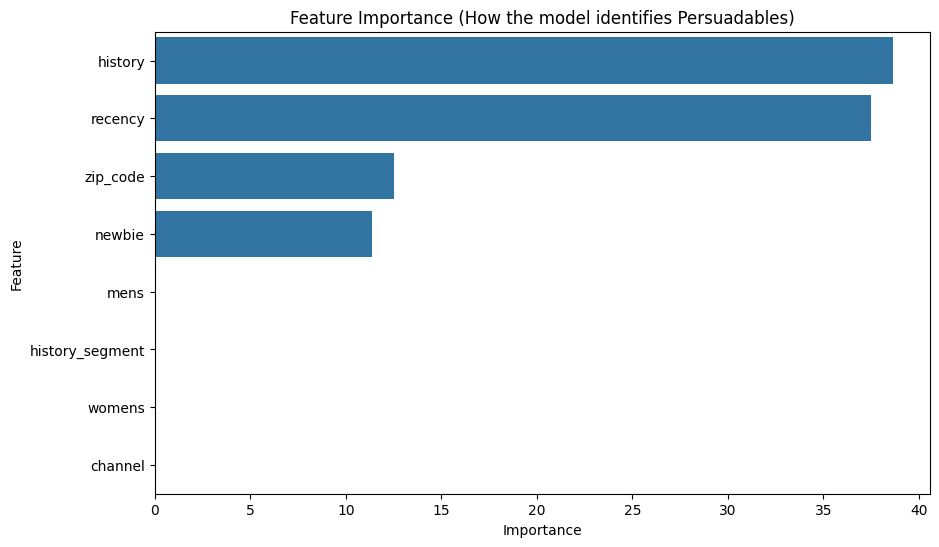

           Feature  Importance
2          history   38.637783
0          recency   37.494634
5         zip_code   12.502882
6           newbie   11.364701
3             mens    0.000000
1  history_segment    0.000000
4           womens    0.000000
7          channel    0.000000


In [34]:
# 1. Get the underlying estimator
# This is the trained CatBoost model
fitted_estimator = ct_model.estimator

# 2. Get the feature importances
# CatBoost provides 'feature_importances_'
importances = fitted_estimator.feature_importances_

# 3. Create a clean DataFrame for viewing
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Plot it
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance (How the model identifies Persuadables)")
plt.show()

print(importance_df)

In [35]:
from sklift.metrics import uplift_at_k
import pandas as pd

k = 0.1

# 1. Calculate for TOP 10% (Using original predictions)
top_train_overall = uplift_at_k(y_train, train_preds, trmnt_train, strategy='overall', k=k)
top_val_overall = uplift_at_k(y_val, val_preds, trmnt_val, strategy='overall', k=k)

# 2. Calculate for BOTTOM 10% (By flipping the sign of the predictions)
# By multiplying by -1, the "lowest" scores become the "highest"
bot_train_overall = uplift_at_k(y_train, -train_preds, trmnt_train, strategy='overall', k=k)
bot_val_overall = uplift_at_k(y_val, -val_preds, trmnt_val, strategy='overall', k=k)

# 3. Create the comparison table
results_df = pd.DataFrame({
    "Segment": ["Top 10% (Original)", "Bottom 10% (Flipped)"],
    "Train Uplift": [top_train_overall, bot_train_overall],
    "Validation Uplift": [top_val_overall, bot_val_overall]
})

print(results_df)

                Segment  Train Uplift  Validation Uplift
0    Top 10% (Original)      0.008389           0.011476
1  Bottom 10% (Flipped)      0.006495          -0.001462


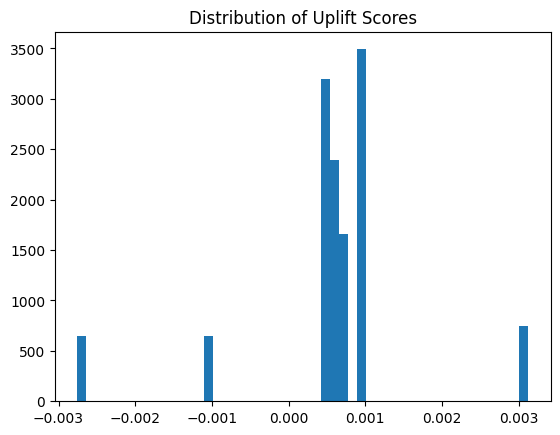

In [36]:
import matplotlib.pyplot as plt
plt.hist(val_preds, bins=50)
plt.title("Distribution of Uplift Scores")
plt.show()

#### Model 2: Regression 

In [78]:
df_spending=df_input[df_input['spend']>0]
df_spending['freq_score'] = df_spending['history'] / (df_spending['recency'] + 1)
df_spending['segment_rank'] = df_spending['history_segment'].astype('category').cat.codes


C:\Users\vncpyy7h\AppData\Local\Temp\ipykernel_31332\432967585.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_spending['freq_score'] = df_spending['history'] / (df_spending['recency'] + 1)
C:\Users\vncpyy7h\AppData\Local\Temp\ipykernel_31332\432967585.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_spending['segment_rank'] = df_spending['history_segment'].astype('category').cat.codes


In [109]:
# Features and Target
X_spend = df_spending.drop(columns=target_cols + ['spend']) # Drop all targets
X_spend = X_spend.reset_index(drop=True)

y_spend = df_spending['spend'].reset_index(drop=True)
y_spend_log = np.log1p(y_spend)

In [110]:
# Fit Regressor
spend_model = CatBoostRegressor(
    iterations=500, depth=3, learning_rate=0.3,
    
    #loss_function='MAE',  
    cat_features=['womens', 'mens', 'channel', 'zip_code', 'history_segment', 'newbie'],
    verbose=0
)
spend_model.fit(X_spend, y_spend_log )

CatBoostRegressor(cat_features=['womens', 'mens', 'channel', 'zip_code', 'history_segment', 'newbie'], depth=3, iterations=500, learning_rate=0.3, loss_function='RMSE', verbose=0)

--- Log-Space Model Evaluation (The 'Brain') ---
MAE (Log): 0.5438
R-squared: 0.3978
Correlation: 0.6604

--- Real-World Dollar Evaluation ---
Average Dollar Error (MAE): $59.43
Correlation (Ranking ability): 0.6420


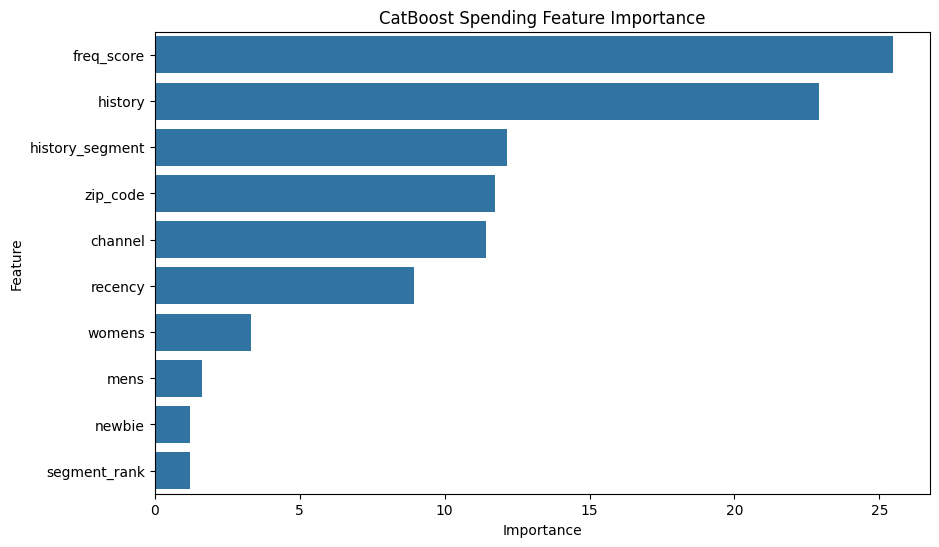

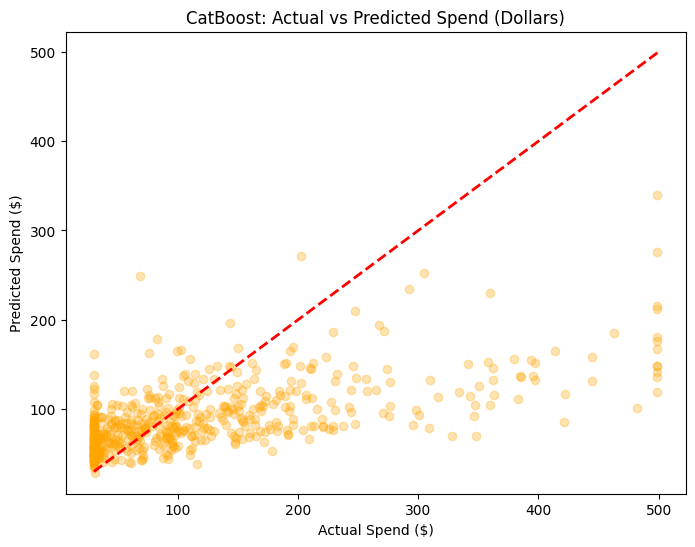

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr

# 1. Generate predictions in Log-Space
y_pred_log = spend_model.predict(X_spend)

# --- A: LOG-SPACE METRICS (Performance of the Brain) ---
mae_log = mean_absolute_error(y_spend_log, y_pred_log)
r2_log = r2_score(y_spend_log, y_pred_log)
corr_log, _ = pearsonr(y_spend_log, y_pred_log)

print(f"--- Log-Space Model Evaluation (The 'Brain') ---")
print(f"MAE (Log): {mae_log:.4f}")
print(f"R-squared: {r2_log:.4f}")
print(f"Correlation: {corr_log:.4f}")

# --- B: DOLLAR-SPACE METRICS (The 'Real-World' Impact) ---
# Convert log-predicted and log-actual back to dollar values
y_pred_dollars = np.expm1(y_pred_log)
y_actual_dollars = np.expm1(y_spend_log)

mae_dollars = mean_absolute_error(y_actual_dollars, y_pred_dollars)
corr_dollars, _ = pearsonr(y_actual_dollars, y_pred_dollars)

print(f"\n--- Real-World Dollar Evaluation ---")
print(f"Average Dollar Error (MAE): ${mae_dollars:.2f}")
print(f"Correlation (Ranking ability): {corr_dollars:.4f}")

# 2. Feature Importance
importance_df = pd.DataFrame({
    'Feature': X_spend.columns,
    'Importance': spend_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("CatBoost Spending Feature Importance")
plt.show()

# 3. Actual vs Predicted Plot (Dollar Space)
plt.figure(figsize=(8, 6))
plt.scatter(y_actual_dollars, y_pred_dollars, alpha=0.3, color='orange')
# Plot a 45-degree line for reference
plt.plot([y_actual_dollars.min(), y_actual_dollars.max()], 
         [y_actual_dollars.min(), y_actual_dollars.max()], 'r--', lw=2)
plt.xlabel('Actual Spend ($)')
plt.ylabel('Predicted Spend ($)')
plt.title('CatBoost: Actual vs Predicted Spend (Dollars)')
plt.show()

In [112]:
X_spend

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,freq_score,segment_rank
0,10,1) $0 - $100,88.37,0,1,Urban,0,Phone,8.033636,0
1,4,3) $200 - $350,297.80,1,1,Urban,0,Phone,59.560000,2
2,10,1) $0 - $100,29.99,0,1,Surburban,0,Web,2.726364,0
3,6,3) $200 - $350,265.61,0,1,Surburban,1,Multichannel,37.944286,2
4,1,2) $100 - $200,101.99,0,1,Surburban,0,Web,50.995000,1
...,...,...,...,...,...,...,...,...,...,...
573,9,5) $500 - $750,536.80,1,1,Rural,1,Web,53.680000,4
574,2,"6) $750 - $1,000",980.39,1,0,Urban,1,Phone,326.796667,5
575,5,3) $200 - $350,210.12,0,1,Surburban,0,Phone,35.020000,2
576,2,3) $200 - $350,215.61,1,0,Rural,0,Web,71.870000,2


In [77]:
X_spend

,recency,history_segment,history,mens,womens,zip_code,newbie,channel
217,10,1) $0 - $100,88.37,0,1,Urban,0,Phone
267,4,3) $200 - $350,297.80,1,1,Urban,0,Phone
332,10,1) $0 - $100,29.99,0,1,Surburban,0,Web
451,6,3) $200 - $350,265.61,0,1,Surburban,1,Multichannel
459,1,2) $100 - $200,101.99,0,1,Surburban,0,Web
...,...,...,...,...,...,...,...,...
63466,9,5) $500 - $750,536.80,1,1,Rural,1,Web
63552,2,"6) $750 - $1,000",980.39,1,0,Urban,1,Phone
63743,5,3) $200 - $350,210.12,0,1,Surburban,0,Phone
63876,2,3) $200 - $350,215.61,1,0,Rural,0,Web


## Pipeline evaluation   
Predict with both classification and regression to see whether expected value worth it 

In [152]:
mens_model_path = 'models/mens_uplift_model.pkl'
womens_model_path = 'models/womens_uplift_model.pkl'

mens_model=joblib.load(mens_model_path)
womens_model=joblib.load(womens_model_path)

mens_features = mens_model.estimator.feature_names_
womens_features = womens_model.estimator.feature_names_


In [153]:
# 2. Select and reorder df_input for each model
# .reindex() is safer than .drop() because it automatically reorders 
# the columns to match your list AND drops unused columns.
df_mens_input = df_input.reindex(columns=mens_features)
df_womens_input = df_input.reindex(columns=womens_features)

# 3. Predict uplift scores
# Now you are 100% sure the column order matches what the model saw during training
df_input['mens_uplift'] = mens_model.predict(df_mens_input)
df_input['womens_uplift'] = womens_model.predict(df_womens_input)

df_input['freq_score'] = df_input['history'] / (df_input['recency'] + 1)
df_input['segment_rank'] = df_input['history_segment'].astype('category').cat.codes


In [154]:
import pandas as pd
import numpy as np
from sklearn.isotonic import IsotonicRegression

def train_uplift_translator(df_val, raw_score_col, treatment_col, target_col):
    """
    df_val: A validation dataset (or your training data if you don't have one)
    raw_score_col: The string name of the column containing the model's prediction
    """
    df = df_val.copy()
    
    # 1. Chop the raw predictions into 15 equal-sized buckets (quantiles)
    df['bucket'] = pd.qcut(df[raw_score_col], q=15, duplicates='drop')
    
    bucket_stats = []
    
    # 2. For each bucket, calculate the ACTUAL real-world uplift
    for bucket_name, group in df.groupby('bucket', observed=True):
        
        # Actual conversion of treated users in this bucket
        treat_conv = group[group[treatment_col] == 1][target_col].mean()
        # Actual conversion of control users in this bucket
        ctrl_conv = group[group[treatment_col] == 0][target_col].mean()
        
        # Safe fallback if a bucket is empty
        treat_conv = 0 if pd.isna(treat_conv) else treat_conv
        ctrl_conv = 0 if pd.isna(ctrl_conv) else ctrl_conv
        
        actual_uplift = treat_conv - ctrl_conv
        avg_raw_score = group[raw_score_col].mean()
        
        bucket_stats.append({
            'avg_raw_score': avg_raw_score,
            'actual_uplift': actual_uplift
        })
        
    stats_df = pd.DataFrame(bucket_stats)
    
    # 3. Train a machine learning Translator (Isotonic Regression)
    # This learns the rule: "When the model says X, the reality is Y"
    translator = IsotonicRegression(out_of_bounds='clip')
    translator.fit(stats_df['avg_raw_score'], stats_df['actual_uplift'])
    
    return translator

In [155]:
df_input['mens_treatment']=np.where(df_input['treatment']=='Mens E-Mail',1,0  )
df_input['womens_treatment']=np.where(df_input['treatment']=='Womens E-Mail',1,0  )

In [157]:
# Assuming you already trained ct_model_A and ct_model_B

# 1. Get raw scores on your historical data
df_input['mens_uplift'] = mens_model.predict(df_mens_input)
df_input['womens_uplift'] = womens_model.predict(df_womens_input)

# 2. Train the Translators
translator_A = train_uplift_translator(df_input, 'mens_uplift', 'mens_treatment', 'visit')
translator_B = train_uplift_translator(df_input, 'womens_uplift', 'womens_treatment', 'visit')

In [158]:
# 2. Translate those scores into TRUE INCREMENTAL CONVERSION
df_input['mens_calibrated_uplift'] = translator_A.predict(df_input['mens_uplift'])
df_input['womens_calibrated_uplift'] = translator_B.predict(df_input['womens_uplift'])

In [123]:
X_spend.columns

Index(['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code',
       'newbie', 'channel', 'freq_score', 'segment_rank'],
      dtype='object')

In [161]:
df_input['predicted_spend_dollars']=np.expm1(spend_model.predict(df_input[X_spend.columns]))


In [162]:
df_input['projected_incremental_revenue'] = (
    df_input['mens_calibrated_uplift'] * df_input['predicted_spend_dollars']
)

df_input=df_input[df_input['treatment']!='Womens E-Mail']

In [163]:
df_input[df_input['treatment']!='Womens E-Mail']['treatment'].value_counts()

treatment
Mens E-Mail    21307
No E-Mail      21306
Name: count, dtype: int64

In [146]:
# Check if any decile is missing either 'Treatment' or 'Control'
check = df_input.groupby('decile').apply(lambda x: x['treatment'].nunique())
print(check)

decile
0    3
1    3
2    3
3    3
4    3
dtype: int64


C:\Users\vncpyy7h\AppData\Local\Temp\ipykernel_31332\2167402025.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  check = df_input.groupby('decile').apply(lambda x: x['treatment'].nunique())


In [165]:
df_input['treatment']=np.where(df_input['treatment']=='No E-Mail', 0, 1)

In [166]:
df_input['treatment'].value_counts()

treatment
1    21307
0    21306
Name: count, dtype: int64

C:\Users\vncpyy7h\AppData\Local\Temp\ipykernel_31332\988471737.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  revenue_lift_table = df_input.groupby('decile').apply(calculate_actual_uplift)


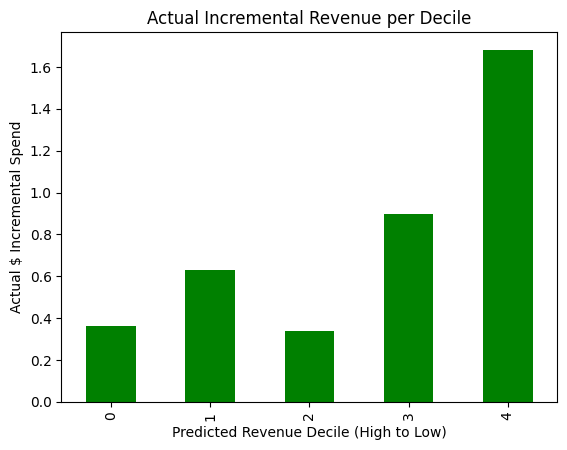

In [167]:
# 1. Create deciles of your projected revenue
df_input['decile'] = pd.qcut(df_input['projected_incremental_revenue'], 5, labels=False, duplicates='drop')

# 2. Calculate the actual spend uplift for each decile
# Formula: Mean(Spend | Treatment) - Mean(Spend | Control)
def calculate_actual_uplift(group):
    # Calculate mean spend for treated and control
    treat_mask = group['treatment'] == 1
    ctrl_mask = group['treatment'] == 0
    
    # Check if we have enough data to calculate uplift
    if treat_mask.sum() == 0 or ctrl_mask.sum() == 0:
        return 0 # Or np.nan
        
    return group.loc[treat_mask, 'spend'].mean() - group.loc[ctrl_mask, 'spend'].mean()
# 3. Group by decile and see if the Uplift increases as the projected revenue increases
revenue_lift_table = df_input.groupby('decile').apply(calculate_actual_uplift)

# 4. Plot it
revenue_lift_table.plot(kind='bar', color='green')
plt.title("Actual Incremental Revenue per Decile")
plt.ylabel("Actual $ Incremental Spend")
plt.xlabel("Predicted Revenue Decile (High to Low)")
plt.show()

In [168]:
revenue_lift_table

decile
0    0.360470
1    0.631698
2    0.339649
3    0.897192
4    1.682293
dtype: float64

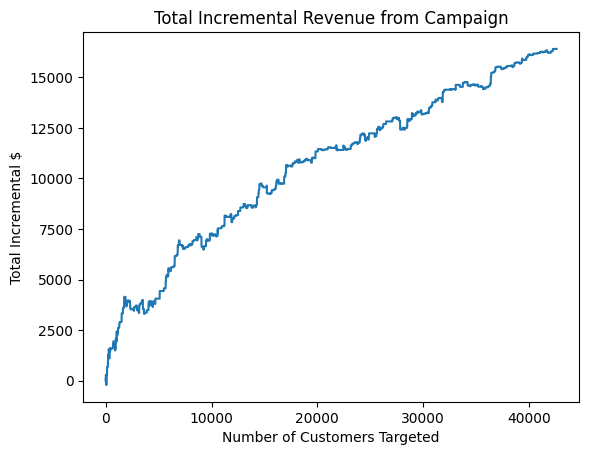

In [169]:
# Calculate cumulative sum of actual uplift
df_input = df_input.sort_values('projected_incremental_revenue', ascending=False)
df_input['cumulative_spend_uplift'] = (df_input['treatment'] * df_input['spend']).cumsum() - \
                                      ((1 - df_input['treatment']) * df_input['spend']).cumsum()

# Plot the total money made as you go down the list
plt.plot(df_input['cumulative_spend_uplift'].values)
plt.title("Total Incremental Revenue from Campaign")
plt.xlabel("Number of Customers Targeted")
plt.ylabel("Total Incremental $")
plt.show()